# Python for AI — Class 18 (Extra)
### How do KNN and the Decision Tree guess a house price?

In Step 3 we tried 3 models. Linear Regression learns a **line** (y = β0 + β1 · x).

**KNN** and the **Decision Tree** do **not** learn a line. Today we open them and see what they do inside, with the same `houses.csv`.

### New words today

| Word | Meaning |
|------|---------|
| **neighbour** | a house in the training data that is **similar** to our new house |
| **distance** | a number that says how **different** two houses are (small = very similar) |
| **K** | how many neighbours KNN looks at (we use 5) |
| **split** | one yes/no question in the tree, like *"size ≤ 10.5?"* |
| **leaf** | the end of a branch. It gives the answer |
| **max_depth** | how many questions the tree can ask, one after another |

## Step 1: Load the data and split (same as class)

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

houses = pd.read_csv("houses.csv")
features = ["size_marla", "bedrooms", "age_years", "distance_km"]

X = houses[features]
y = houses["price_lakh"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", len(X_train), "houses")
print("Test: ", len(X_test), "houses")

Train: 160 houses
Test:  40 houses


We follow **one new house** from the test data. The model has **never seen** it.

In [5]:
new_house = X_test.iloc[[0]]      # first house in the test data
real_price = y_test.iloc[0]

print(new_house)
print("Real price:", real_price, "lakh")

    size_marla  bedrooms  age_years  distance_km
95          16         7          3          8.2
Real price: 185.4 lakh


# Part 1: KNN (K-Nearest Neighbours)

- **Idea:** similar houses have similar prices.
- `fit` does **no maths**. It only **saves** the 160 training houses.
- `predict` finds the **5 most similar** houses and takes their **average price**.

In [6]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)      # only saves the training houses

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


## Step 2: Find the 5 nearest houses

`kneighbors` tells us **which** 5 houses KNN picked and **how far** each one is.

In [7]:
distances, rows = knn.kneighbors(new_house)

neighbours = X_train.iloc[rows[0]].copy()
neighbours["price_lakh"] = y_train.iloc[rows[0]].values
neighbours["distance"] = distances[0].round(2)
neighbours

,size_marla,bedrooms,age_years,distance_km,price_lakh,distance
103,17,7,1,7.7,210.8,2.29
70,16,7,6,10.1,172.7,3.55
181,15,7,5,11.1,172.8,3.66
10,18,6,5,10.3,178.1,3.66
127,15,7,0,10.4,183.7,3.85


- All 5 houses are **15 to 18 marla** with **6 or 7 bedrooms**, like our new house (16 marla, 7 bedrooms).
- The closest one (distance **2.29**) is almost the same house.

## Step 3: How is the distance calculated?

For each column: **subtract**, then **square**. Add them all up. Take the **square root**.

Example: new house vs the closest neighbour:

| | size | bedrooms | age | km |
|--|--|--|--|--|
| new house | 16 | 7 | 3 | 8.2 |
| neighbour | 17 | 7 | 1 | 7.7 |
| difference² | 1 | 0 | 4 | 0.25 |

√(1 + 0 + 4 + 0.25) = √5.25 = **2.29**

In [8]:
import numpy as np

a = new_house.iloc[0].values      # the new house
b = neighbours.iloc[0][features].values.astype(float)   # closest neighbour

distance = np.sqrt(((a - b) ** 2).sum())
print("Distance by hand:", round(distance, 2))

Distance by hand: 2.29


## Step 4: Take the average price

In [21]:
print("Average of the 5 prices:", round(neighbours["price_lakh"].mean(), 2))
print("knn.predict:            ", knn.predict(new_house).round(2))
print("Real price:             ", real_price)

Average of the 5 prices: 183.62
knn.predict:             [183.62]
Real price:              185.4


Same number. **KNN = the average price of the 5 most similar houses.**

### Quick Check 1
Use **K = 3**. Take the average of the **first 3** neighbours by hand. Then check with `KNeighborsRegressor(n_neighbors=3)`.

In [10]:
# your code here

**Answer:**

In [11]:
print("By hand:", round(neighbours["price_lakh"].head(3).mean(), 2))

knn3 = KNeighborsRegressor(n_neighbors=3)
knn3.fit(X_train, y_train)
print("Model:  ", knn3.predict(new_house).round(2))

By hand: 185.43
Model:   [185.43]


# Part 2: Decision Tree

- **Idea:** ask **yes/no questions**, like a flowchart.
- `fit` **learns the questions**. It tries many questions and keeps the one that puts houses with **similar prices** in the same group.
- Each **leaf** (end of a branch) stores the **average price** of the training houses that end there.
- `predict` sends the new house down the tree and gives that leaf's price.

We use `max_depth=2` (only 2 questions), so the tree is small enough to read.

In [12]:
from sklearn.tree import DecisionTreeRegressor, export_text

tree = DecisionTreeRegressor(max_depth=2, random_state=42)
tree.fit(X_train, y_train)      # learns the questions

print(export_text(tree, feature_names=features))

|--- size_marla <= 10.50
|   |--- size_marla <= 5.50
|   |   |--- value: [34.89]
|   |--- size_marla >  5.50
|   |   |--- value: [80.09]
|--- size_marla >  10.50
|   |--- size_marla <= 15.50
|   |   |--- value: [130.30]
|   |--- size_marla >  15.50
|   |   |--- value: [182.99]



The tree only asks about **size**. Size is the strongest feature (remember the correlation in Step 1 of class).

Draw it as a picture:

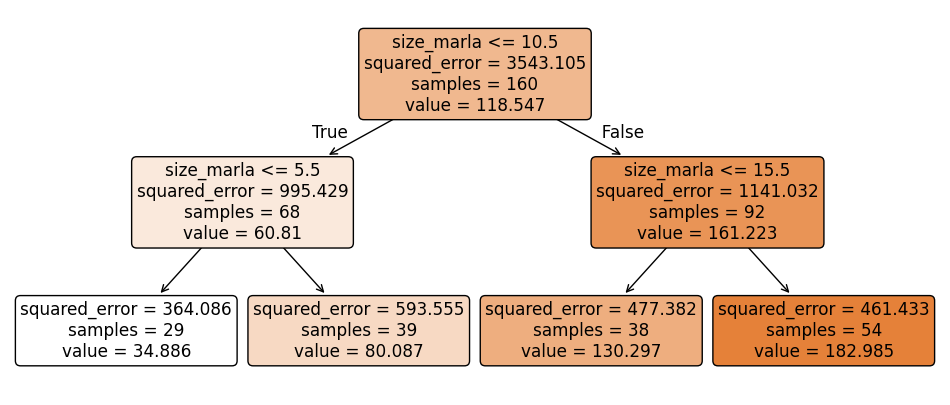

In [13]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12, 5))
plot_tree(tree, feature_names=features, filled=True, rounded=True)
plt.show()

- `samples` = how many training houses reached that box.
- `value` = their **average price**.

## Step 5: Check one leaf by hand

The leaf **size > 15.5** says **182.99**. That should be the average price of all training houses bigger than 15.5 marla.

In [14]:
big = X_train["size_marla"] > 15.5
print("Houses in this leaf:", big.sum())
print("Their average price:", round(y_train[big].mean(), 2))

Houses in this leaf: 54
Their average price: 182.99


## Step 6: Follow our new house down the tree

New house = **16 marla**.
1. size ≤ 10.5? **No** → go right
2. size ≤ 15.5? **No** → go right
3. Leaf: **182.99 lakh**

In [15]:
print("tree.predict:", tree.predict(new_house).round(2))
print("Real price:  ", real_price)

tree.predict: [182.99]
Real price:   185.4


### Quick Check 2
A house is **8 marla**, 4 bedrooms, 10 years old, 12 km away. Follow the tree **by hand** first. Then check with `tree.predict`.

In [16]:
# your code here

**Answer:** 8 ≤ 10.5 → **Yes**. 8 ≤ 5.5 → **No**. Leaf = **80.09 lakh**.

In [17]:
house_8 = pd.DataFrame({"size_marla": [8], "bedrooms": [4], "age_years": [10], "distance_km": [12]})
print(tree.predict(house_8).round(2))

[80.09]


# Part 3: All 3 models on the same house

In [18]:
from sklearn.linear_model import LinearRegression

line = LinearRegression()
line.fit(X_train, y_train)

print("Real price:        ", real_price)
print("Linear Regression: ", line.predict(new_house).round(1))
print("KNN (K=5):         ", knn.predict(new_house).round(1))
print("Decision Tree:     ", tree.predict(new_house).round(1))

Real price:         185.4
Linear Regression:  [184.1]
KNN (K=5):          [183.6]
Decision Tree:      [183.]


| Model | What `fit` does | What `predict` does |
|-------|-----------------|---------------------|
| **Linear Regression** | finds β0 and β1 (the best line) | puts the numbers into the line |
| **KNN** | only **saves** the training houses | average price of the **5 nearest** houses |
| **Decision Tree** | learns the **yes/no questions** | follows the questions, gives the leaf's average |

Only Linear Regression is an **equation**. KNN **remembers**. The tree **asks questions**.

All 3 models give a good guess for **this one house**. To choose the best model, we still check the error on **all** the test houses (like Step 3 of class).

## The complete program

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor, export_text

# Step 1: load and split
houses = pd.read_csv("houses.csv")
features = ["size_marla", "bedrooms", "age_years", "distance_km"]
X = houses[features]
y = houses["price_lakh"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
new_house = X_test.iloc[[0]]

# KNN: find the 5 nearest houses, take their average price
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
distances, rows = knn.kneighbors(new_house)
print("5 nearest prices:", y_train.iloc[rows[0]].values)
print("KNN guess:", knn.predict(new_house).round(1))

# Decision Tree: learn the questions, follow them
tree = DecisionTreeRegressor(max_depth=2, random_state=42)
tree.fit(X_train, y_train)
print(export_text(tree, feature_names=features))
print("Tree guess:", tree.predict(new_house).round(1))
print("Real price:", y_test.iloc[0])

5 nearest prices: [210.8 172.7 172.8 178.1 183.7]
KNN guess: [183.6]
|--- size_marla <= 10.50
|   |--- size_marla <= 5.50
|   |   |--- value: [34.89]
|   |--- size_marla >  5.50
|   |   |--- value: [80.09]
|--- size_marla >  10.50
|   |--- size_marla <= 15.50
|   |   |--- value: [130.30]
|   |--- size_marla >  15.50
|   |   |--- value: [182.99]

Tree guess: [183.]
Real price: 185.4


# Home Problem: cars.csv

Do the same steps with `cars.csv`. Features: `car_age`, `km_thousands`, `engine_cc`. Target: `price_lakh`.

1. Load the data. Split with `test_size=0.2, random_state=42`.
2. Take the first test car as `new_car`. Print it and its real price.
3. **KNN:** fit with K = 5. Show the 5 nearest cars with their prices and distances.
4. Take the average of the 5 prices by hand. Check it with `knn.predict`.
5. **Tree:** fit with `max_depth=2`. Print it with `export_text`.
6. Follow `new_car` down the tree by hand. Check with `tree.predict`.
7. **Think:** look at the 5 nearest cars. Which column decides the distance the most? Why? (Hint: look at how big the numbers in each column are.)

In [20]:
# your code here